In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import joblib
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers


In [2]:

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)


In [3]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
file_path = os.path.join(path, [f for f in os.listdir(path) if f.endswith('.csv')][0])

# Load into DataFrame  (keep original and we will work on a copy)
df_raw = pd.read_csv(file_path)
df = df_raw.copy()

print("=" * 100)
print("  DATASET OVERVIEW")
print("=" * 100)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"  Columns : {df.columns.tolist()}")
print("=" * 100)
df.head()

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
  DATASET OVERVIEW
  Rows    : 2200
  Columns : 8
  Columns : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.8797,82.0027,6.5030,202.9355,rice
1,85,58,41,21.7705,80.3196,7.0381,226.6555,rice
2,60,55,44,23.0045,82.3208,7.8402,263.9642,rice
3,74,35,40,26.4911,80.1584,6.9804,242.8640,rice
4,78,42,42,20.1302,81.6049,7.6285,262.7173,rice


In [4]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0000,50.5518,36.9173,0.0000,21.0000,37.0000,84.2500,140.0000
P,2200.0000,53.3627,32.9859,5.0000,28.0000,51.0000,68.0000,145.0000
K,2200.0000,48.1491,50.6479,5.0000,20.0000,32.0000,49.0000,205.0000
temperature,2200.0000,25.6162,5.0637,8.8257,22.7694,25.5987,28.5617,43.6755
humidity,2200.0000,71.4818,22.2638,14.2580,60.2620,80.4731,89.9488,99.9819
ph,2200.0000,6.4695,0.7739,3.5048,5.9717,6.4250,6.9236,9.9351
rainfall,2200.0000,103.4637,54.9584,20.2113,64.5517,94.8676,124.2675,298.5601


In [5]:
print("Class Distribution (number of samples per crop):")
dist = df['label'].value_counts()
print(dist)
print(f"\nTotal classes : {dist.nunique()}")
print(f"Min samples   : {dist.min()}  ({dist.idxmin()})")
print(f"Max samples   : {dist.max()}  ({dist.idxmax()})")

Class Distribution (number of samples per crop):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Total classes : 1
Min samples   : 100  (rice)
Max samples   : 100  (rice)


Feature distributions

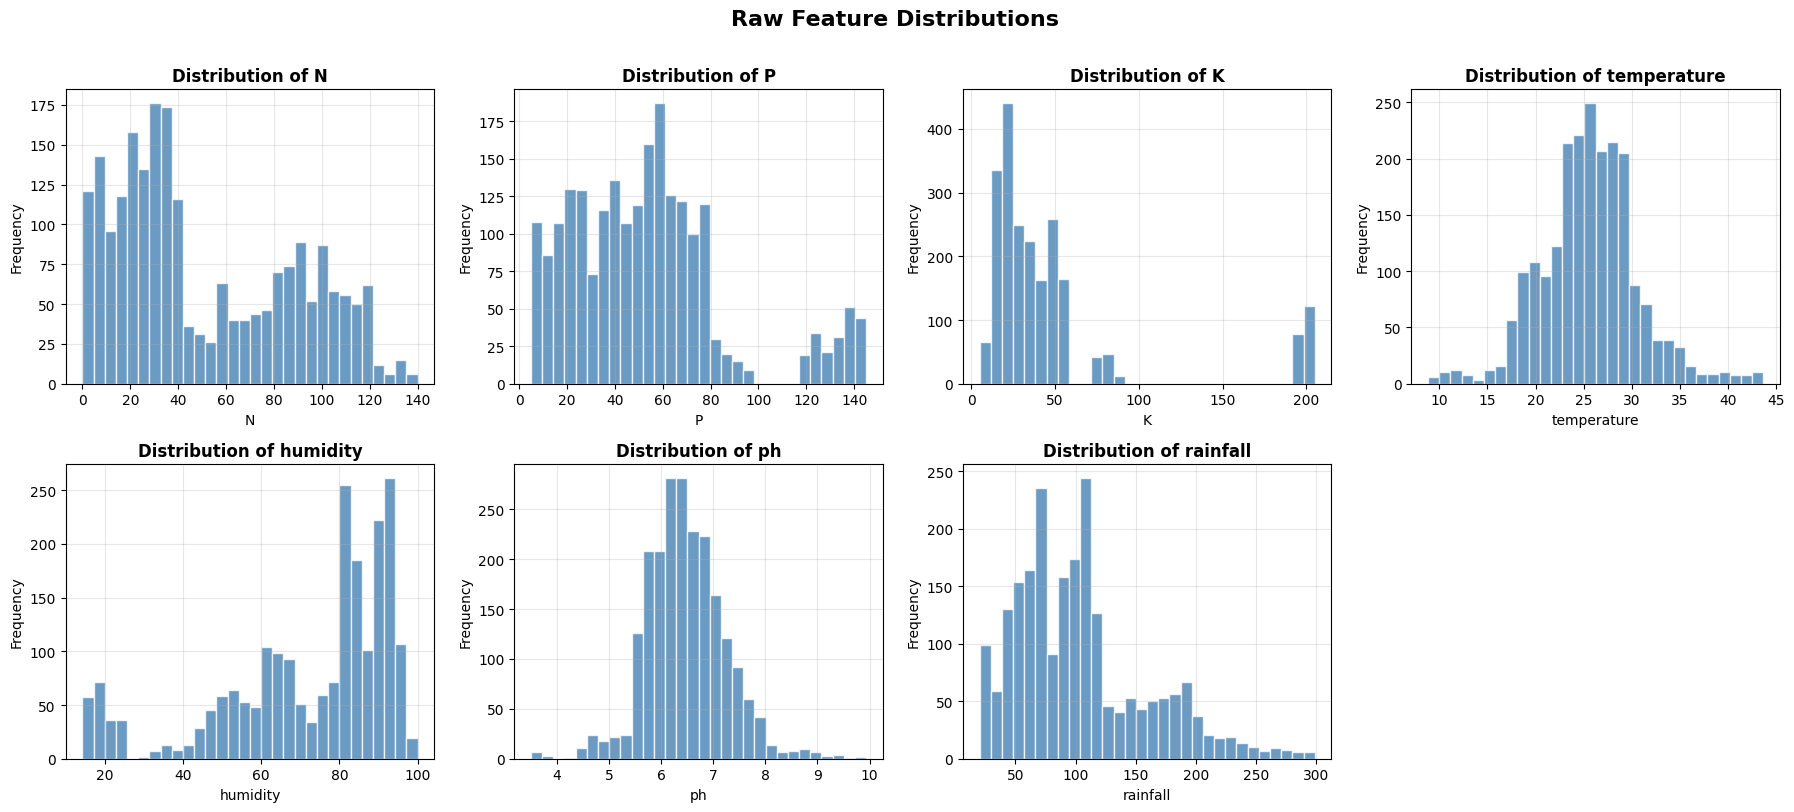

✓ Saved: eda_distributions.png


In [6]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Raw Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: eda_distributions.png")

 Correlation heatmap (raw numeric features only)

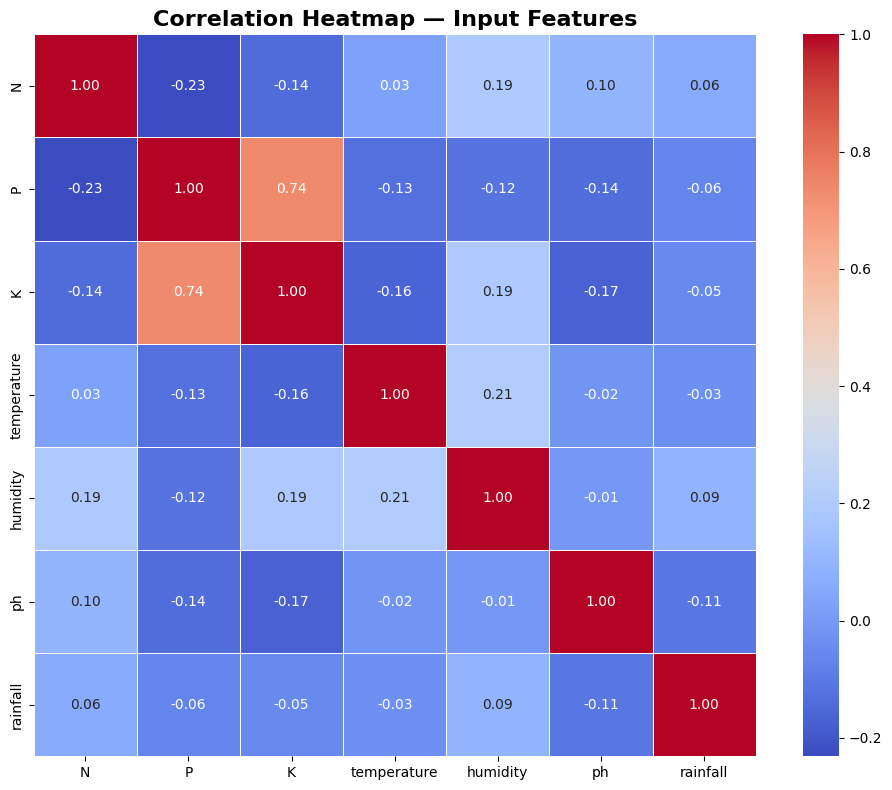

✓ Saved: eda_correlation.png


In [7]:
plt.figure(figsize=(10, 8))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Input Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: eda_correlation.png")

Box-plot: Rainfall by crop

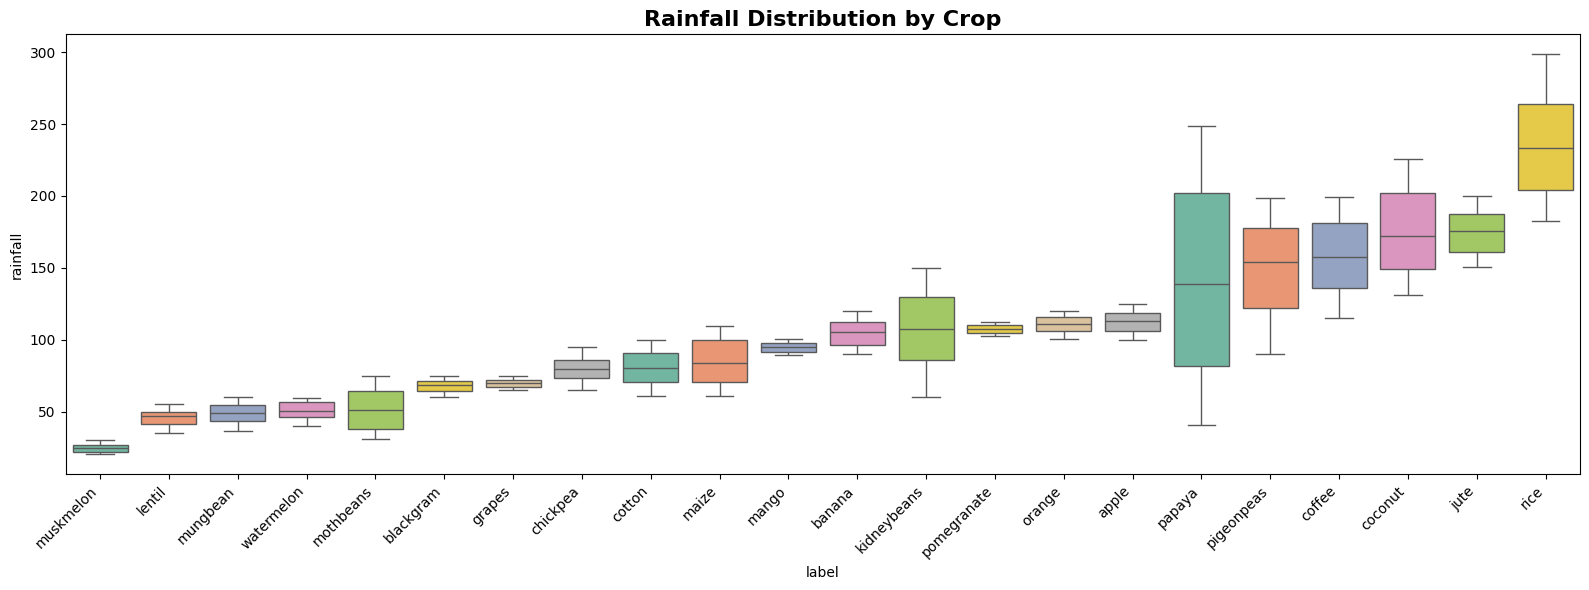

✓ Saved: eda_rainfall_boxplot.png


In [8]:
plt.figure(figsize=(16, 6))
order = df.groupby('label')['rainfall'].median().sort_values().index
sns.boxplot(x='label', y='rainfall', data=df, order=order, palette='Set2')
plt.title('Rainfall Distribution by Crop', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_rainfall_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: eda_rainfall_boxplot.png")

#Scatter: Nitrogen vs Rainfall

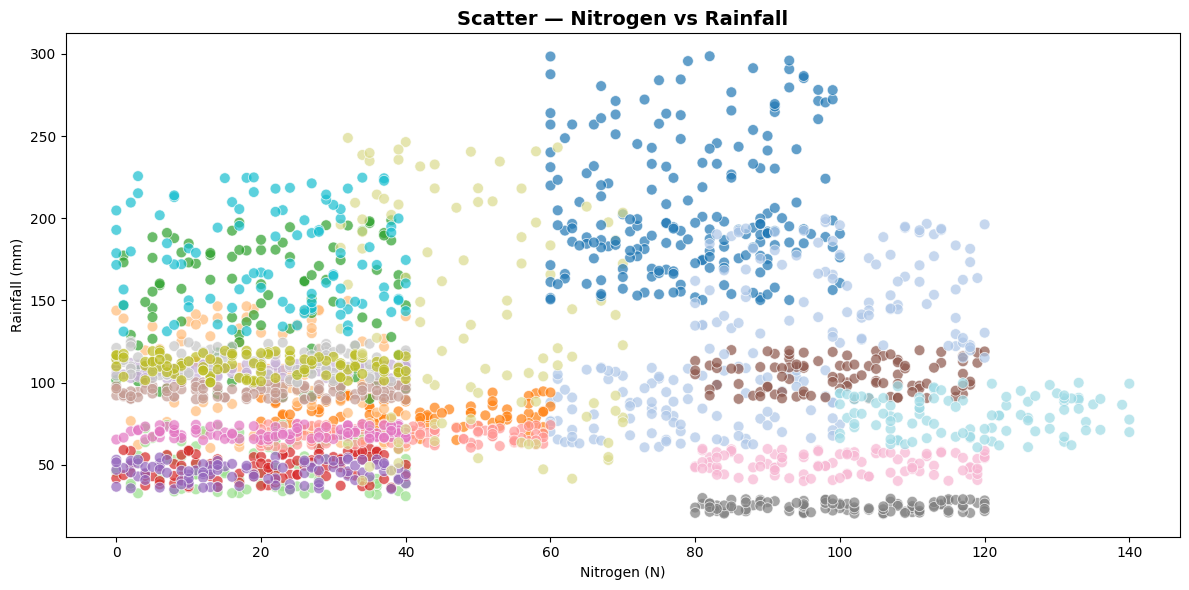

✓ Saved: eda_scatter_N_rainfall.png


In [9]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='N', y='rainfall', hue='label',
                palette='tab20', s=60, alpha=0.7, legend=False)
plt.title('Scatter — Nitrogen vs Rainfall', fontsize=14, fontweight='bold')
plt.xlabel('Nitrogen (N)')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.savefig('eda_scatter_N_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: eda_scatter_N_rainfall.png")

In [10]:
print("=" * 100)
print("  DATA INTEGRITY REPORT")
print("=" * 100)

# 1.Missing values
missing = df.isnull().sum()
total_missing = missing.sum()
print(f"\n[1] Missing Values (per column):")
print(missing)
print(f"    → Total missing : {total_missing}")

# 2.Duplicate rows
n_duplicates = df.duplicated().sum()
print(f"\n[2] Duplicate Rows : {n_duplicates}")
if n_duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"    → Removed {n_duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("    → No duplicates found.")

# 3.Dtypes
print("\n[3] Data Types:")
print(df.dtypes)
print("=" * 100)

  DATA INTEGRITY REPORT

[1] Missing Values (per column):
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
    → Total missing : 0

[2] Duplicate Rows : 0
    → No duplicates found.

[3] Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


#Outlier Detection using IQR

In [11]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

print("Outlier Report (IQR method):")
print(f"{'Feature':<15} {'#Outliers':>10} {'Lower':>12} {'Upper':>12}")
print("-" * 52)
for col in feature_cols:
    n_out, lo, hi = detect_outliers_iqr(df, col)
    print(f"{col:<15} {n_out:>10} {lo:>12.3f} {hi:>12.3f}")

print("\n⚠  RobustScaler (used in pre-processing) handles outliers")
print("   automatically — no rows need to be dropped.")

Outlier Report (IQR method):
Feature          #Outliers        Lower        Upper
----------------------------------------------------
N                        0      -73.875      179.125
P                      138      -32.000      128.000
K                      200      -23.500       92.500
temperature             86       14.081       37.250
humidity                30       15.732      134.479
ph                      57        4.544        8.352
rainfall               100      -25.022      213.841

⚠  RobustScaler (used in pre-processing) handles outliers
   automatically — no rows need to be dropped.


#Step 1 : Label Encoding

In [12]:
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['label'])

crop_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Crop → Integer mapping:")
for k, v in crop_mapping.items():
    print(f"  {k:>15} → {v}")
print(f"\nTotal classes: {len(encoder.classes_)}")

Crop → Integer mapping:
            apple → 0
           banana → 1
        blackgram → 2
         chickpea → 3
          coconut → 4
           coffee → 5
           cotton → 6
           grapes → 7
             jute → 8
      kidneybeans → 9
           lentil → 10
            maize → 11
            mango → 12
        mothbeans → 13
         mungbean → 14
        muskmelon → 15
           orange → 16
           papaya → 17
       pigeonpeas → 18
      pomegranate → 19
             rice → 20
       watermelon → 21

Total classes: 22


#Step 2 : Train / Validation / Test Split

In [13]:
X = df[feature_cols].values
y = df['label_encoded'].values

# 70 % train | 15 % val | 15 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("=" * 45)
print("  SPLIT SUMMARY")
print("=" * 45)
print(f"  Training   : {X_train.shape[0]:>5} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation : {X_val.shape[0]:>5} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]:>5} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features   : {X_train.shape[1]}")
print("=" * 45)

  SPLIT SUMMARY
  Training   :  1540 samples  (70.0%)
  Validation :   330 samples  (15.0%)
  Test       :   330 samples  (15.0%)
  Features   : 7


#  Step 3 : Feature Scaling (fit ONLY on train)

In [14]:
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("RobustScaler fitted on TRAINING set only — no data leakage.")
print(f"   Train mean (post-scale) ≈ {X_train_sc.mean():.4f}  (should be ≈ 0)")
print(f"   Train std  (post-scale) ≈ {X_train_sc.std():.4f}   (should be ≈ 1)")

RobustScaler fitted on TRAINING set only — no data leakage.
   Train mean (post-scale) ≈ 0.1055  (should be ≈ 0)
   Train std  (post-scale) ≈ 1.0411   (should be ≈ 1)


In [15]:
from tensorflow.keras.regularizers import l2

NUM_CLASSES = len(encoder.classes_)

model = keras.Sequential([
    #  Block 1
    layers.Dense(256, kernel_regularizer=l2(1e-4),
                 input_shape=(X_train_sc.shape[1],)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    #  Block 2
    layers.Dense(128, kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Block 3 (bottleneck — no Dropout)
    layers.Dense(64, kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    #Output
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='CropRecommendation_ANN')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "CropRecommendation_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,422 (181.34 KB)

 Trainable params: 45,526 (177.84 KB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
os.makedirs('model_artifacts', exist_ok=True)

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=10, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'model_artifacts/best_model.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    )
]

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),   #  explicit val set — no leakage
    epochs=150,
    batch_size=64,
    callbacks=cb_list,
    verbose=1
)

print("\n Training complete.")

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1644 - loss: 2.9800
Epoch 1: val_loss improved from None to 2.71814, saving model to model_artifacts/best_model.keras

Epoch 1: finished saving model to model_artifacts/best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.2864 - loss: 2.5968 - val_accuracy: 0.6152 - val_loss: 2.7181 - learning_rate: 0.0010
Epoch 2/150
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5483 - loss: 1.8781 
Epoch 2: val_loss improved from 2.71814 to 2.42301, saving model to model_artifacts/best_model.keras

Epoch 2: finished saving model to model_artifacts/best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6058 - loss: 1.7326 - val_accuracy: 0.7606 - val_loss: 2.4230 - learning_rate: 0.0010
Epoch 3/150
20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6973 - loss: 1.3926 
Epoch 3: val_loss improved from 2.42301 to 2.15928, saving model to model_artifacts/best_model.keras

Epoch 3: finished savin

In [17]:
# Predictions on held-out TEST set
y_pred_proba = model.predict(X_test_sc, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("=" * 55)
print("  TEST SET PERFORMANCE")
print("=" * 55)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=encoder.classes_,
                            zero_division=0))

  TEST SET PERFORMANCE
  Accuracy  : 0.9909
  Precision : 0.9918
  Recall    : 0.9909
  F1 Score  : 0.9909

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       0.94      1.00      0.97        15
      grapes       1.00      1.00      1.00        15
        jute       0.88      1.00      0.94        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      0.93      0.97        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   m

# Training History

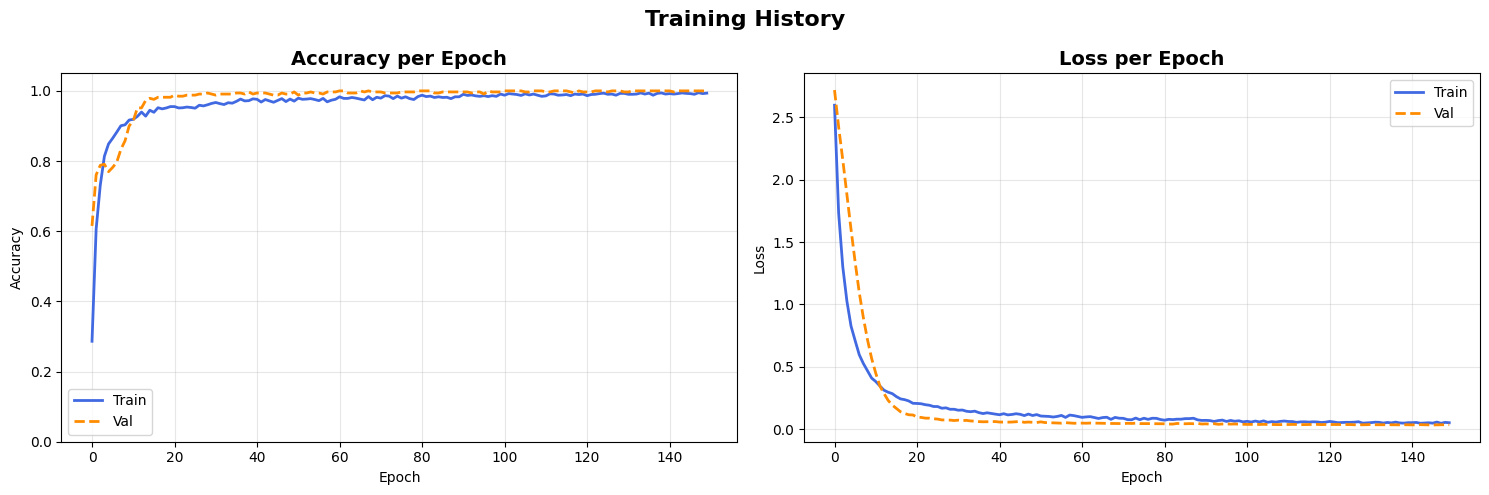

✓ Saved: training_history.png


In [18]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'],     label='Train', linewidth=2, color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2, color='darkorange', linestyle='--')
ax1.set_title('Accuracy per Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylim([0, 1.05])

ax2.plot(history.history['loss'],     label='Train', linewidth=2, color='royalblue')
ax2.plot(history.history['val_loss'], label='Val',   linewidth=2, color='darkorange', linestyle='--')
ax2.set_title('Loss per Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: training_history.png")

# Confusion Matrix

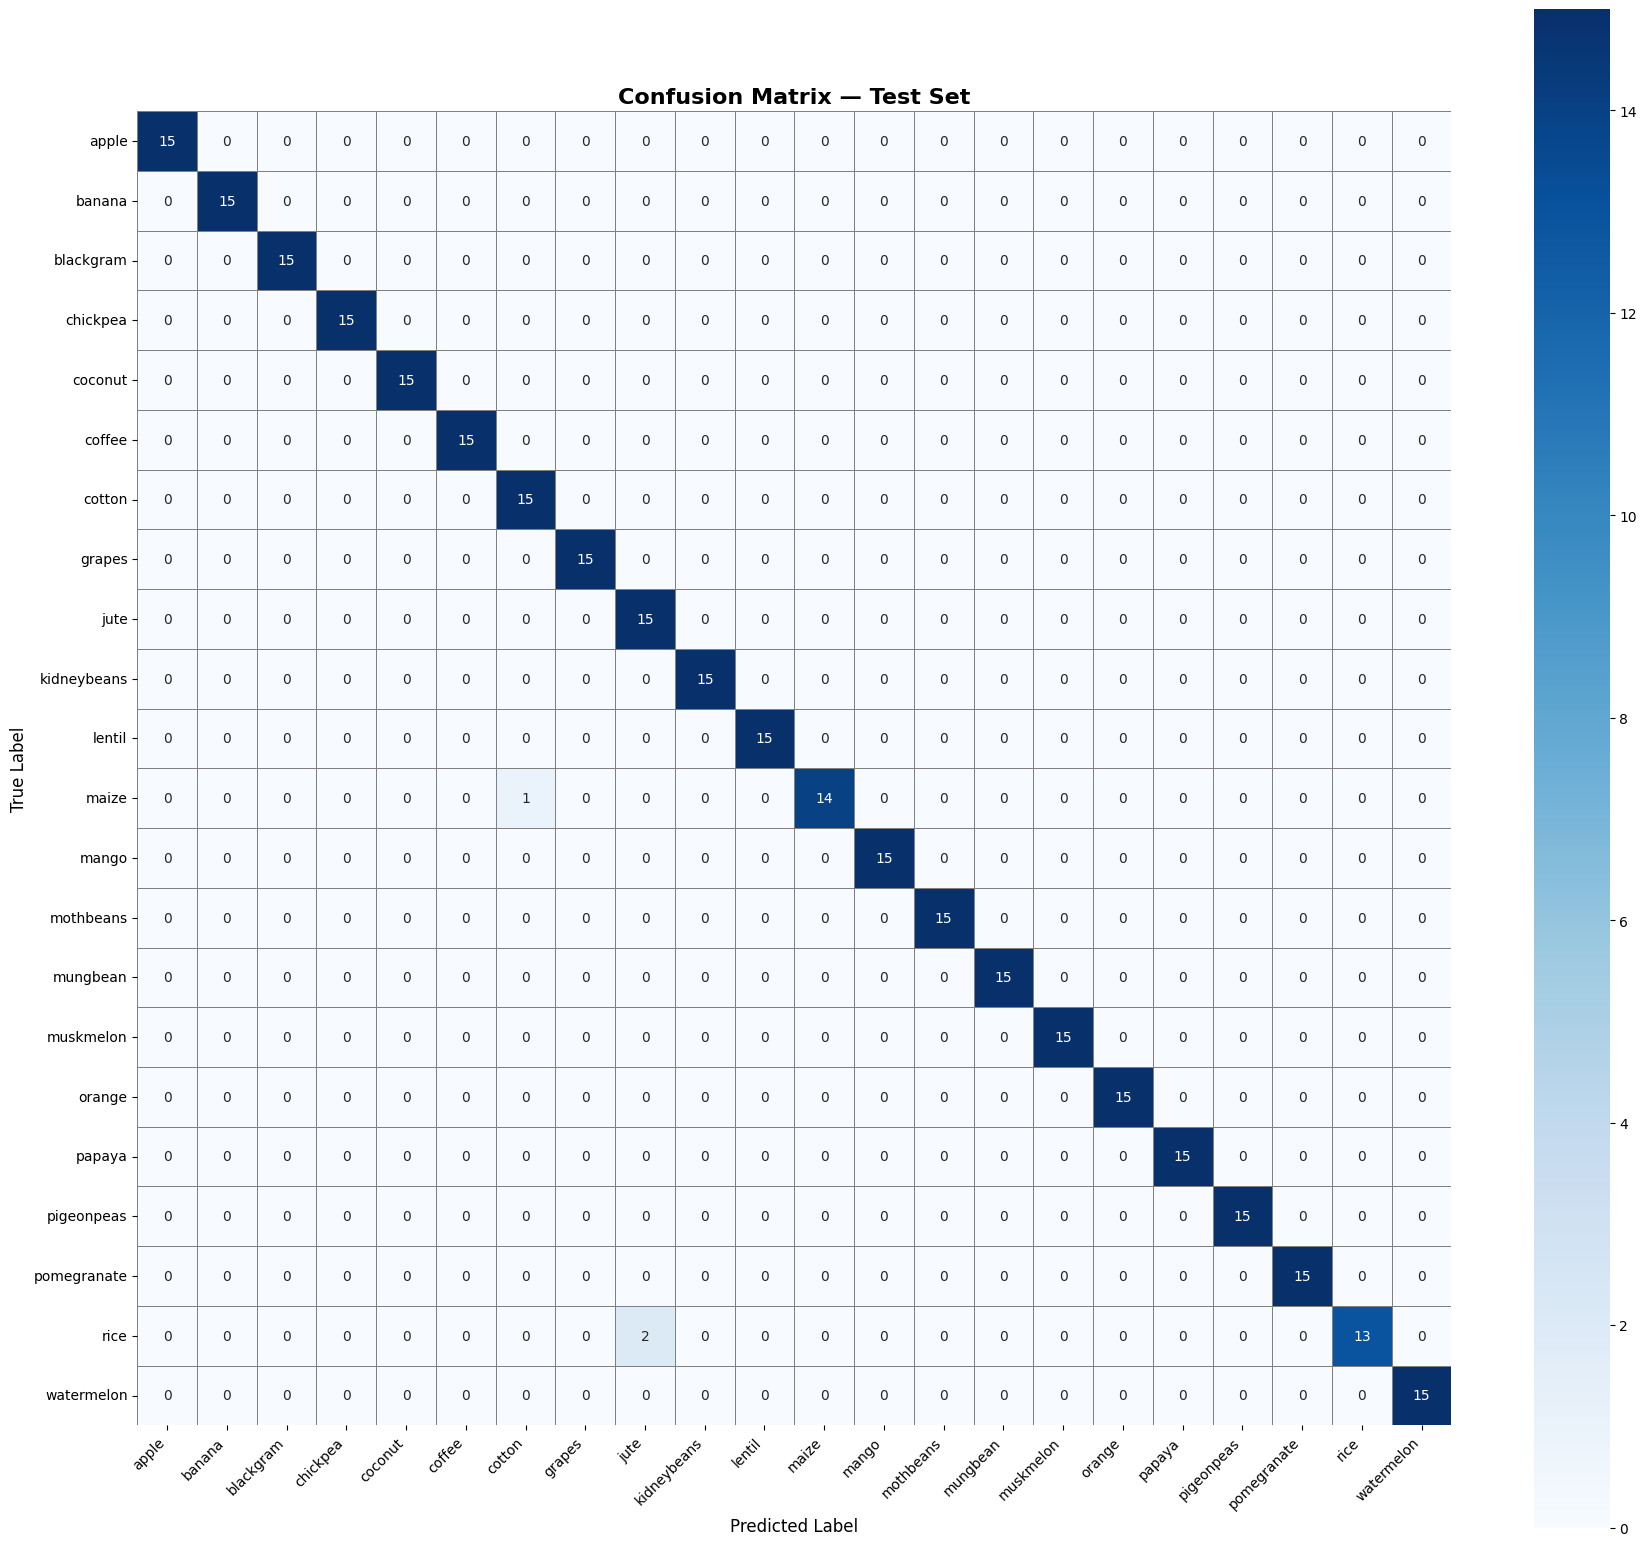

✓ Saved: confusion_matrix.png


In [19]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            square=True, linewidths=0.4, linecolor='grey')
plt.title('Confusion Matrix — Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: confusion_matrix.png")

# Metrics Bar Chart

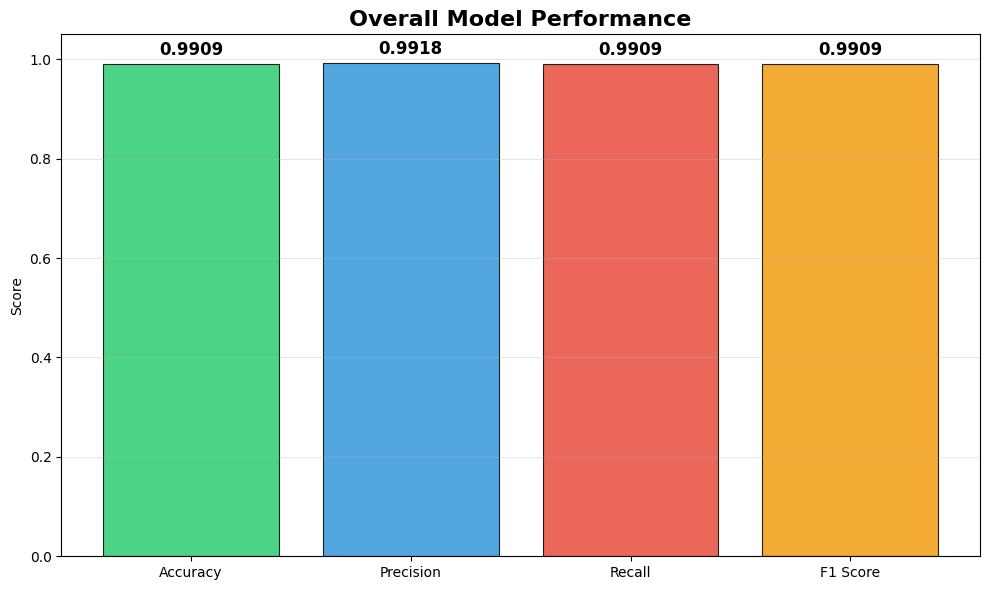

✓ Saved: metrics_bar.png


In [20]:

metric_labels  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values  = [accuracy, precision, recall, f1]
bar_colors     = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

plt.figure(figsize=(10, 6))
bars = plt.bar(metric_labels, metric_values,
               color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
plt.ylim(0, 1.05)
plt.title('Overall Model Performance', fontsize=16, fontweight='bold')
plt.ylabel('Score')
plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: metrics_bar.png")

bar chart

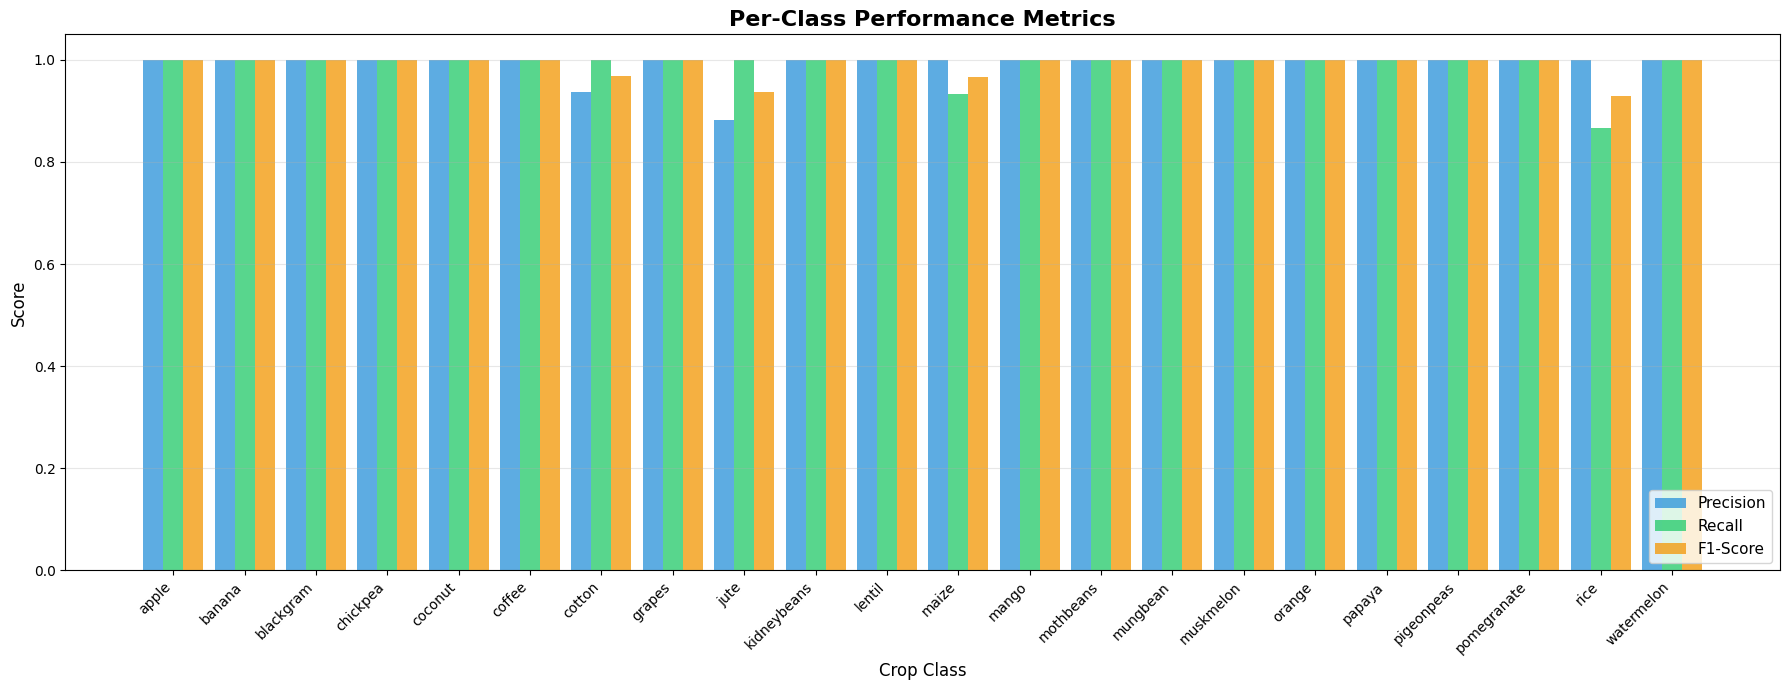

✓ Saved: per_class_metrics.png


In [21]:

pc_precision = precision_score(y_test, y_pred, average=None, zero_division=0)
pc_recall    = recall_score(y_test, y_pred, average=None, zero_division=0)
pc_f1        = f1_score(y_test, y_pred, average=None, zero_division=0)

x = np.arange(len(encoder.classes_))
width = 0.28

fig, ax = plt.subplots(figsize=(18, 7))
ax.bar(x - width, pc_precision, width, label='Precision', color='#3498db', alpha=0.8)
ax.bar(x,         pc_recall,    width, label='Recall',    color='#2ecc71', alpha=0.8)
ax.bar(x + width, pc_f1,        width, label='F1-Score',  color='#f39c12', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(encoder.classes_, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Crop Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: per_class_metrics.png")

In [22]:
# ── Model (Keras + H5 for compatibility)
model.save('model_artifacts/crop_recommendation_model.keras')
model.save('model_artifacts/crop_recommendation_model.h5')

# ── Scaler & Encoder
joblib.dump(scaler,  'model_artifacts/scaler.pkl')
joblib.dump(encoder, 'model_artifacts/label_encoder.pkl')

# ── Metrics Summary
report_str = classification_report(y_test, y_pred,
                                   target_names=encoder.classes_,
                                   zero_division=0)
with open('model_artifacts/metrics_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("CROP RECOMMENDATION ANN — PERFORMANCE SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Accuracy  : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"F1 Score  : {f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report_str)

# ── Per-class CSV
pd.DataFrame({
    'Class': encoder.classes_,
    'Precision': pc_precision,
    'Recall': pc_recall,
    'F1-Score': pc_f1
}).to_csv('model_artifacts/per_class_metrics.csv', index=False)

print(" All artifacts saved to ./model_artifacts/")
print("   • crop_recommendation_model.keras")
print("   • crop_recommendation_model.h5")
print("   • best_model.keras")
print("   • scaler.pkl")
print("   • label_encoder.pkl")
print("   • metrics_summary.txt")
print("   • per_class_metrics.csv")

 All artifacts saved to ./model_artifacts/
   • crop_recommendation_model.keras
   • crop_recommendation_model.h5
   • best_model.keras
   • scaler.pkl
   • label_encoder.pkl
   • metrics_summary.txt
   • per_class_metrics.csv


In [23]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict the best crop for given soil & weather conditions.

    Parameters
    ----------
    N, P, K         : Nitrogen, Phosphorus, Potassium content in soil
    temperature     : Temperature in °C
    humidity        : Relative humidity in %
    ph              : Soil pH value
    rainfall        : Rainfall in mm

    Returns
    -------
    dict with predicted_crop, confidence, and top_3 predictions
    """
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    features_sc = scaler.transform(features)
    proba = model.predict(features_sc, verbose=0)[0]

    top_3_idx = np.argsort(proba)[-3:][::-1]
    top_3 = [(encoder.classes_[i], round(float(proba[i]) * 100, 2)) for i in top_3_idx]

    return {
        'predicted_crop': top_3[0][0],
        'confidence':     top_3[0][1],
        'top_3':          top_3
    }

# Example prediction
result = predict_crop(N=90, P=42, K=43,
                      temperature=20.8, humidity=82.0,
                      ph=6.5, rainfall=202.9)

print("=" * 55)
print("  🌾 CROP PREDICTION")
print("=" * 55)
print(f"  Input   : N=90, P=42, K=43, T=20.8°C, H=82%, pH=6.5, R=202.9mm")
print(f"  → Crop  : {result['predicted_crop']}")
print(f"  → Conf  : {result['confidence']:.2f}%")
print("\n  Top-3 Predictions:")
for crop, prob in result['top_3']:
    bar = '█' * int(prob / 5)
    print(f"    {crop:>15} : {prob:>6.2f}%  {bar}")
print("=" * 55)

  🌾 CROP PREDICTION
  Input   : N=90, P=42, K=43, T=20.8°C, H=82%, pH=6.5, R=202.9mm
  → Crop  : rice
  → Conf  : 99.33%

  Top-3 Predictions:
               rice :  99.33%  ███████████████████
               jute :   0.66%  
             coffee :   0.00%  
